# Diabetes Progression Prediction

## Project Overview

In questo progetto sviluppo un modello di machine learning per prevedere la progressione del diabete a un anno di distanza, utilizzando un dataset clinico reale.

L’obiettivo è simulare uno scenario applicativo in ambito sanitario, in cui modelli predittivi possono supportare il monitoraggio dei pazienti e facilitare interventi più tempestivi e personalizzati.

## Dataset

Il dataset utilizzato è il **Diabetes dataset** disponibile in scikit-learn, contenente 442 osservazioni e 10 variabili cliniche già standardizzate.

Le feature rappresentano misurazioni fisiologiche e biochimiche dei pazienti (età, BMI, pressione sanguigna, lipidi, glucosio, ecc.), mentre il target indica la progressione della malattia dopo un anno.

Fonte originale:
https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html

Riferimento accademico:
Efron, B., Hastie, T., Johnstone, I., Tibshirani, R. (2004).  
*Least Angle Regression*, Annals of Statistics.

## Approach

Il progetto segue un flusso strutturato:

- analisi esplorativa dei dati (EDA)
- definizione di un modello baseline (Linear Regression)
- introduzione di un modello regolarizzato (Ridge Regression)
- ottimizzazione degli iperparametri tramite cross-validation
- valutazione delle prestazioni e interpretazione dei risultati

Particolare attenzione è dedicata all’interpretabilità del modello, aspetto cruciale nel contesto sanitario.

## Linear Model Assumption

Il modello utilizzato si basa sull’assunzione di una relazione lineare tra le variabili indipendenti e il target.

In particolare, il modello cerca di approssimare la relazione nella forma:

y = w0 + w1x1 + w2x2 + ... + wnxn

dove i coefficienti rappresentano il contributo di ciascuna variabile alla previsione finale.

Questa scelta è motivata dalla necessità di mantenere un buon livello di interpretabilità, fondamentale nel contesto sanitario.

In [1]:
# Import delle librerie principali per analisi dati e machine learning
import pandas as pd
import numpy as np

# Import del dataset Diabetes direttamente da scikit-learn
from sklearn.datasets import load_diabetes

# Carico il dataset
diabetes = load_diabetes()

# Creo un DataFrame pandas utilizzando le feature
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

# Aggiungo la variabile target (progressione della malattia)
df['target'] = diabetes.target

# Visualizzo le prime righe del dataset per un primo controllo
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Data Preparation

In questa fase preparo il dataset per l’analisi rendendo i nomi delle variabili più interpretabili.

Le feature presenti nel dataset originale sono abbreviate (es. s1, s2, s3...), quindi le rinomino con termini più descrittivi per facilitare la lettura, l’analisi e l’interpretazione dei risultati nelle fasi successive.

In [2]:
# Rinomino le colonne per renderle più leggibili e interpretabili
df = df.rename(columns={
    'age': 'age',
    'sex': 'sex',
    'bmi': 'body_mass_index',
    'bp': 'blood_pressure',
    's1': 'tc',   # total cholesterol
    's2': 'ldl',  # low-density lipoproteins
    's3': 'hdl',  # high-density lipoproteins
    's4': 'tch',  # total cholesterol / HDL
    's5': 'ltg',  # log of serum triglycerides
    's6': 'glu',  # blood sugar level
    'target': 'disease_progression'
})

# Controllo
df.head()

,age,sex,body_mass_index,blood_pressure,tc,ldl,hdl,tch,ltg,glu,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Data Understanding

In questa fase analizzo le caratteristiche principali del dataset per comprenderne la struttura e individuare eventuali criticità.

In particolare:
- verifico dimensioni e tipi di dati
- controllo la presenza di valori mancanti
- osservo le statistiche descrittive delle variabili

Questo passaggio è fondamentale per capire come procedere nelle fasi successive ed evitare errori nell’analisi.

In [3]:
# Dimensioni del dataset (righe, colonne)
print("Shape del dataset:", df.shape)

# Informazioni generali (tipi di dati, null)
df.info()

# Verifica valori mancanti
print("\nValori mancanti per colonna:")
print(df.isnull().sum())

# Statistiche descrittive
df.describe()

Shape del dataset: (442, 11)
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   body_mass_index      442 non-null    float64
 3   blood_pressure       442 non-null    float64
 4   tc                   442 non-null    float64
 5   ldl                  442 non-null    float64
 6   hdl                  442 non-null    float64
 7   tch                  442 non-null    float64
 8   ltg                  442 non-null    float64
 9   glu                  442 non-null    float64
 10  disease_progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Valori mancanti per colonna:
age                    0
sex                    0
body_mass_index        0
blood_pressure         0
tc                     0
ldl                    0
hdl  

,age,sex,body_mass_index,blood_pressure,tc,ldl,hdl,tch,ltg,glu,disease_progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Dall’analisi delle statistiche descrittive emergono alcuni aspetti rilevanti.

Le variabili indipendenti risultano già standardizzate: tutte presentano una media prossima a zero e una deviazione standard simile (~0.047). Questo indica che il dataset è già stato preprocessato, facilitando l’utilizzo di modelli sensibili alla scala delle feature, come quelli lineari regolarizzati.

Non sono presenti valori mancanti, quindi non è necessario effettuare operazioni di pulizia o imputazione.

La variabile target (disease_progression) presenta una distribuzione su una scala molto più ampia rispetto alle feature, con valori compresi tra 25 e 346 e una deviazione standard elevata (~77). Questo suggerisce una variabilità significativa nella progressione della malattia tra i pazienti.

Infine, il dataset contiene un numero relativamente ridotto di osservazioni (442), il che rende necessario prestare attenzione al rischio di overfitting e utilizzare tecniche di validazione robuste come la cross-validation nelle fasi successive.

## Exploratory Data Analysis

In questa fase esploro la distribuzione della variabile target e le relazioni tra le feature.

L’obiettivo è individuare pattern rilevanti e comprendere quali variabili potrebbero influenzare maggiormente la progressione della malattia.

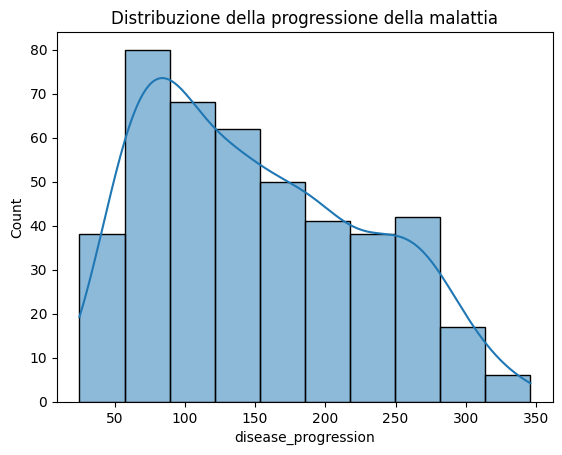

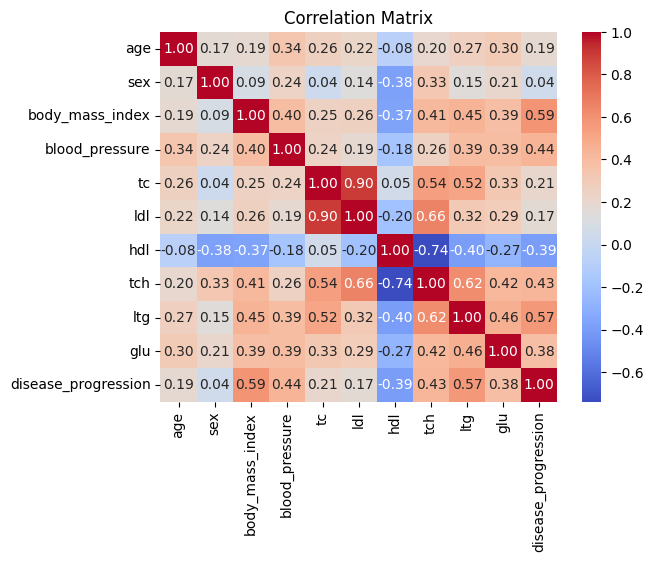

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribuzione target
plt.figure()
sns.histplot(df['disease_progression'], kde=True)
plt.title("Distribuzione della progressione della malattia")
plt.show()

# Correlation matrix
plt.figure()
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Dall’analisi esplorativa emergono alcune evidenze rilevanti.

La distribuzione della variabile target (disease_progression) appare leggermente asimmetrica verso destra, con una maggiore concentrazione di valori tra 50 e 200 e una coda che si estende verso valori più elevati. Questo suggerisce la presenza di alcuni casi con progressione più severa della malattia.

Si osserva inoltre che tutte le feature presentano media prossima a 0 e deviazione standard molto simile, indicando che i dati sono già stati standardizzati. Questo è particolarmente utile per modelli come la Ridge Regression, che risultano sensibili alla scala delle variabili.

Dalla matrice di correlazione si osserva che alcune variabili mostrano una relazione significativa con il target. In particolare:
- body_mass_index (bmi) presenta una correlazione positiva piuttosto elevata (~0.59)
- ltg (trigliceridi) mostra una correlazione positiva rilevante (~0.57)
- blood_pressure e tch presentano correlazioni moderate

Al contrario, hdl mostra una correlazione negativa con la progressione della malattia, suggerendo un possibile effetto protettivo.

Inoltre, si notano forti correlazioni tra alcune feature (ad esempio tc e ldl), indicando la presenza di multicollinearità. Questo aspetto rende particolarmente adatti modelli regolarizzati come Ridge Regression, che aiutano a gestire queste dipendenze tra variabili.

## Feature Engineering

In questa fase rendo esplicite le decisioni prese sulle feature prima dell’addestramento del modello.

Anche se il dataset risulta già pulito e standardizzato, è importante motivare in modo consapevole le scelte effettuate: quali variabili mantenere, come gestire la multicollinearità osservata durante l’EDA e se siano necessarie ulteriori trasformazioni.

L’obiettivo non è modificare artificialmente il dataset, ma verificare che la struttura delle feature sia coerente con il tipo di modello scelto.

In [5]:
# Calcolo la correlazione delle feature con il target
target_corr = df.corr()['disease_progression'].drop('disease_progression').sort_values(
    key=lambda x: x.abs(), ascending=False
)

print("Correlazione delle feature con il target:")
print(target_corr)

# Calcolo la matrice di correlazione tra le sole feature
feature_corr = df.drop(columns='disease_progression').corr().abs()

# Tengo solo il triangolo superiore per evitare duplicati
upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

# Seleziono le coppie con correlazione alta
high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
)

print("\nCoppie di feature con correlazione elevata:")
print(high_corr_pairs[high_corr_pairs > 0.7])

Correlazione delle feature con il target:
body_mass_index    0.586450
ltg                0.565883
blood_pressure     0.441482
tch                0.430453
hdl               -0.394789
glu                0.382483
tc                 0.212022
age                0.187889
ldl                0.174054
sex                0.043062
Name: disease_progression, dtype: float64

Coppie di feature con correlazione elevata:
tc   ldl    0.896663
hdl  tch    0.738493
dtype: float64


Dall’analisi delle correlazioni emergono alcune considerazioni utili per la gestione delle feature.

Alcune variabili, in particolare body_mass_index e ltg, mostrano una forte relazione con il target, confermando il loro ruolo rilevante nel modello. Al contrario, variabili come sex presentano una correlazione molto bassa (~0.04), suggerendo un contributo limitato alla predizione.

Nonostante ciò, si decide di mantenere tutte le feature nel modello. Anche variabili debolmente correlate possono contribuire in modo combinato alla previsione, e la regressione lineare è in grado di gestire queste informazioni senza necessità di esclusione preventiva.

Per quanto riguarda le relazioni tra feature, si osserva una forte correlazione tra tc e ldl (~0.90) e una correlazione elevata tra hdl e tch. Questo evidenzia la presenza di multicollinearità, che potrebbe influenzare negativamente un modello lineare standard.

Tuttavia, la scelta di utilizzare Ridge Regression permette di gestire questo problema in modo efficace, distribuendo il peso tra variabili correlate e riducendo l’instabilità dei coefficienti.

Infine, non vengono applicate ulteriori trasformazioni o scaling, in quanto il dataset risulta già standardizzato alla fonte. Questa scelta è coerente con l’utilizzo di modelli regolarizzati, che beneficiano di feature sulla stessa scala.

## Baseline Model

Inizio con un modello di regressione lineare semplice per stabilire un punto di riferimento.

Questo permette di valutare successivamente se l’introduzione della regolarizzazione (Ridge Regression) porta a un miglioramento delle prestazioni.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separazione feature e target
X = df.drop('disease_progression', axis=1)
y = df['disease_progression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modello baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predizioni
y_pred = baseline_model.predict(X_test)

# Metriche
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 42.79409467959994
RMSE: 53.85344583676592
R2: 0.4526027629719196


Il modello di regressione lineare fornisce un primo punto di riferimento per la previsione della progressione della malattia.

Il Mean Absolute Error (MAE) è pari a circa 42.8, indicando che in media il modello sbaglia di circa 43 unità nella previsione del target. Considerando che il target varia tra 25 e 346, l’errore non è trascurabile.

Il Root Mean Squared Error (RMSE) è pari a circa 53.9, valore più elevato rispetto al MAE, suggerendo la presenza di errori più marcati su alcuni casi (outlier o pazienti con progressione più estrema).

L’R² pari a circa 0.45 indica che il modello riesce a spiegare circa il 45% della variabilità della progressione della malattia. Questo valore evidenzia che il modello cattura alcune relazioni nei dati, ma lascia ancora una parte significativa non spiegata.

Nel complesso, il modello baseline offre prestazioni discrete ma migliorabili, rendendo sensato l’utilizzo di tecniche di regolarizzazione per ottenere risultati più robusti.

## Ridge Regression

Per migliorare le prestazioni del modello baseline, utilizzo la Ridge Regression.

La scelta di utilizzare modelli lineari è guidata dalla necessità di mantenere un elevato livello di interpretabilità. In ambito sanitario, comprendere il contributo delle variabili è spesso più importante rispetto a ottenere il massimo delle performance predittive.

Questo modello introduce un termine di regolarizzazione che penalizza coefficienti troppo elevati, aiutando a gestire la multicollinearità tra le feature e a ridurre il rischio di overfitting.

Dato che durante l’analisi esplorativa sono emerse forti correlazioni tra alcune variabili, l’utilizzo di un modello regolarizzato risulta particolarmente appropriato.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Definizione del modello
ridge = Ridge()

# Nuova griglia di iperparametri (estesa verso valori più piccoli)
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search con cross-validation
grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Fit
grid_search.fit(X_train, y_train)

# Miglior modello
best_model = grid_search.best_estimator_

print("Best alpha:", grid_search.best_params_)

Best alpha: {'alpha': 0.1}


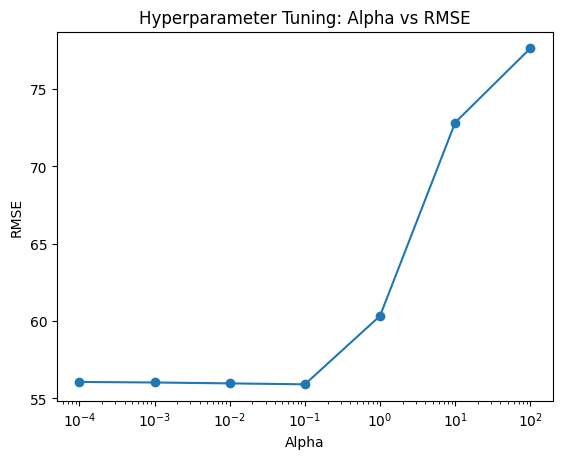

In [8]:
# Estraggo i risultati della cross-validation
results = pd.DataFrame(grid_search.cv_results_)

# Converto il punteggio in RMSE
results['rmse'] = np.sqrt(-results['mean_test_score'])

# Plot alpha vs RMSE
plt.figure()
plt.plot(results['param_alpha'], results['rmse'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Hyperparameter Tuning: Alpha vs RMSE')
plt.show()

La ricerca degli iperparametri tramite GridSearchCV ha confermato come valore ottimale di alpha 0.1 anche dopo l’estensione della griglia verso valori più piccoli.

Il grafico dei risultati mostra che per alpha compresi tra 0.0001 e 0.1 il valore di RMSE rimane quasi invariato, segnalando che il modello è poco sensibile a regolarizzazioni molto deboli e che, in questa zona, il comportamento resta vicino a quello della regressione lineare standard.

A partire da valori di alpha più elevati, invece, l’errore cresce in modo evidente. Questo indica che una penalizzazione troppo forte semplifica eccessivamente il modello, riducendone la capacità predittiva.

La scelta di utilizzare GridSearchCV è appropriata in questo caso, poiché lo spazio degli iperparametri è piccolo, discreto e composto da un solo parametro. Una ricerca esaustiva consente quindi di confrontare tutti i valori in modo diretto e trasparente.

Strategie come RandomizedSearchCV o Bayesian Optimization risultano più utili in scenari con spazi di ricerca molto più ampi o continui, dove una ricerca completa sarebbe meno efficiente.

## Model Evaluation

Valuto le prestazioni del modello Ridge utilizzando le stesse metriche impiegate per il modello baseline.

Questo permette un confronto diretto per verificare se la regolarizzazione ha effettivamente migliorato la capacità predittiva del modello.

In [9]:
# Predizioni con il miglior modello Ridge
y_pred_ridge = best_model.predict(X_test)

# Metriche
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MAE: 42.99693214159653
Ridge RMSE: 53.446111997699646
Ridge R2: 0.46085219464119265


Il modello Ridge mostra prestazioni leggermente migliori rispetto alla regressione lineare baseline, ma con alcune differenze interessanti tra le metriche.

Il MAE aumenta leggermente (da **~42.8** a **~43.0**), indicando un piccolo peggioramento nell’errore medio assoluto. Questo suggerisce che, in media, le predizioni non risultano più accurate rispetto al modello lineare semplice.

Al contrario, il RMSE diminuisce e il valore di R² aumenta, indicando una migliore gestione degli errori più elevati e una maggiore capacità del modello di spiegare la variabilità del target.

Questa combinazione di risultati suggerisce che la Ridge Regression non migliora uniformemente tutte le predizioni, ma contribuisce a ridurre l’impatto degli errori più grandi, rendendo il modello complessivamente più stabile.

In un contesto applicativo, questo comportamento può essere preferibile, poiché ridurre errori estremi è spesso più importante che ottimizzare esclusivamente l’errore medio.

## Cross-Validated Evaluation

Per ottenere una stima più robusta delle prestazioni del modello finale, affianco alla valutazione sul singolo test set una validazione incrociata.

Con un dataset di dimensioni relativamente ridotte, una singola suddivisione train-test può introdurre variabilità nei risultati. La cross-validation permette invece di misurare le performance su più suddivisioni dei dati, fornendo una valutazione più stabile e affidabile.

In [10]:
from sklearn.model_selection import cross_validate

# Valuto il modello finale con cross-validation
cv_results = cross_validate(
    Ridge(alpha=0.1),
    X,
    y,
    cv=5,
    scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error')
)

# Calcolo metriche medie e deviazioni standard
cv_r2_mean = cv_results['test_r2'].mean()
cv_r2_std = cv_results['test_r2'].std()

cv_mae_mean = -cv_results['test_neg_mean_absolute_error'].mean()
cv_mae_std = cv_results['test_neg_mean_absolute_error'].std()

cv_rmse_scores = np.sqrt(-cv_results['test_neg_mean_squared_error'])
cv_rmse_mean = cv_rmse_scores.mean()
cv_rmse_std = cv_rmse_scores.std()

print("Cross-validated R2: {:.4f} ± {:.4f}".format(cv_r2_mean, cv_r2_std))
print("Cross-validated MAE: {:.4f} ± {:.4f}".format(cv_mae_mean, cv_mae_std))
print("Cross-validated RMSE: {:.4f} ± {:.4f}".format(cv_rmse_mean, cv_rmse_std))

Cross-validated R2: 0.4799 ± 0.0473
Cross-validated MAE: 44.6362 ± 1.9068
Cross-validated RMSE: 54.8250 ± 0.9610


La cross-validation fornisce una stima più robusta delle prestazioni del modello finale rispetto alla sola valutazione su un singolo test set.

Il modello Ridge con alpha = 0.1 ottiene un R² medio di circa 0.48, con una deviazione standard contenuta (~0.05), indicando una capacità predittiva moderatamente stabile tra i diversi fold.

Anche MAE e RMSE mostrano una variabilità limitata, suggerendo che il comportamento del modello è abbastanza coerente al variare della suddivisione dei dati.

Nel complesso, questi risultati confermano che le performance osservate sul test set non dipendono soltanto da uno split favorevole, ma riflettono una tendenza più generale del modello sul dataset.

## Residual Analysis

Per approfondire il comportamento del modello, analizzo i residui, ossia la differenza tra valori reali e valori predetti.

Nel caso di un modello lineare, l’osservazione dei residui è utile per verificare se gli errori risultano distribuiti in modo casuale oppure se emergono pattern sistematici, che potrebbero suggerire limiti nella capacità del modello di rappresentare la struttura dei dati.

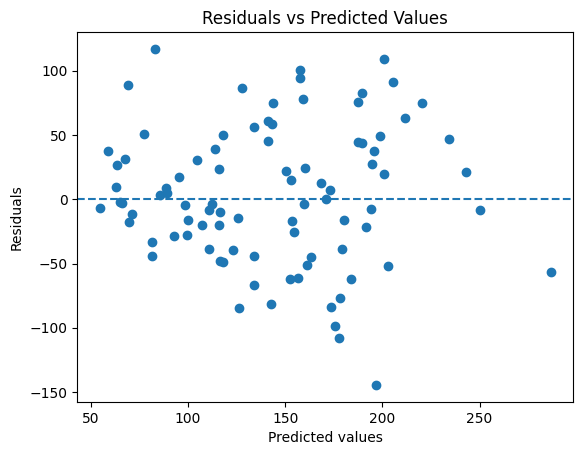

In [11]:
# Calcolo dei residui
residuals = y_test - y_pred_ridge

# Grafico residui vs valori predetti
plt.figure()
plt.scatter(y_pred_ridge, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

L’analisi dei residui mostra una distribuzione complessivamente centrata attorno allo zero, suggerendo che il modello non presenta bias sistematici evidenti nelle predizioni.

I punti risultano distribuiti in modo abbastanza casuale, senza pattern fortemente strutturati, indicando che il modello lineare riesce a catturare una parte significativa della relazione tra le variabili.

Tuttavia, si osserva una certa dispersione dei residui, con alcuni errori più marcati soprattutto per valori predetti più elevati. Questo suggerisce che il modello potrebbe avere difficoltà nel rappresentare correttamente i casi con progressione più estrema della malattia.

Nel complesso, il comportamento dei residui è coerente con le metriche osservate: il modello è sufficientemente stabile, ma non cattura completamente tutta la variabilità presente nei dati.

## Model Interpretability

Analizzo i coefficienti del modello Ridge per comprendere quali variabili influenzano maggiormente la previsione della progressione della malattia.

Questo è particolarmente importante in ambito sanitario, dove l’interpretabilità del modello è fondamentale.

In [12]:
# Coefficienti del modello
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
})

# Ordino per importanza (valore assoluto)
coefficients['abs_coeff'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='abs_coeff', ascending=False)

coefficients[['Feature', 'Coefficient']]

,Feature,Coefficient
2,body_mass_index,505.089033
8,ltg,392.289319
3,blood_pressure,317.093205
1,sex,-205.494319
6,hdl,-190.363180
7,tch,151.707086
4,tc,-108.500262
5,ldl,-86.236733
9,glu,79.908177
0,age,42.855670


L’analisi dei coefficienti del modello Ridge evidenzia quali variabili influenzano maggiormente la previsione della progressione della malattia.

Le feature con impatto più rilevante risultano essere body_mass_index (bmi) e ltg (trigliceridi), entrambe con coefficienti positivi elevati, seguite da blood_pressure. Questi risultati sono coerenti con quanto osservato durante l’analisi esplorativa, dove tali variabili mostravano una forte correlazione con il target.

Al contrario, hdl presenta un coefficiente negativo significativo, suggerendo un’associazione inversa con la progressione della malattia, in linea con il suo ruolo protettivo.

La presenza di coefficienti distribuiti tra variabili correlate (come tc e ldl) riflette l’effetto della regolarizzazione introdotta dalla Ridge Regression, che gestisce la multicollinearità evitando pesi eccessivamente instabili.

Nel complesso, il modello conferma che indicatori metabolici come BMI e trigliceridi rappresentano fattori chiave nella progressione del diabete, offrendo insight coerenti sia con i dati che con il contesto clinico.

## Conclusion

In questo progetto è stato sviluppato un modello di regressione per prevedere la progressione del diabete a partire da variabili cliniche.

Il modello baseline ha mostrato prestazioni discrete, mentre l’introduzione della Ridge Regression ha portato a un miglioramento nella stabilità delle predizioni e nella capacità di generalizzazione, come confermato sia dal test set sia dalla cross-validation.

L’analisi dei coefficienti ha evidenziato come fattori metabolici, in particolare body mass index e livelli di trigliceridi, abbiano un impatto rilevante sulla progressione della malattia, in coerenza con quanto osservato durante l’EDA.

L’analisi dei residui ha inoltre mostrato una distribuzione complessivamente casuale, suggerendo che il modello lineare cattura una parte significativa della struttura dei dati, pur presentando limiti nella gestione dei casi più estremi.

Nonostante le buone prestazioni, il modello presenta alcune limitazioni:
- dataset di dimensioni ridotte
- dati già preprocessati, con limitata possibilità di feature engineering
- relazioni modellate principalmente in forma lineare

In prospettiva, l’utilizzo di modelli più complessi o dataset più ampi potrebbe migliorare ulteriormente le prestazioni. Tuttavia, il modello sviluppato rappresenta un buon compromesso tra interpretabilità e accuratezza, aspetto fondamentale in ambito sanitario.